In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
df=pd.read_csv('insurance.csv')

In [142]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01


In [143]:
df.tail(3)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87
1339,1340,30.00,female,47.40,101,No,0,Yes,southeast,63770.43


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [145]:
df.shape

(1340, 10)

In [146]:
pd.set_option("display.float_format","{:.2f}".format)

In [147]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [148]:
sns.set(style="whitegrid",palette="Set2",font_scale=1.1)

In [149]:

df.duplicated().sum()

np.int64(0)

In [150]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [151]:
df.dropna(inplace=True)

In [152]:
df.shape

(1332, 10)

In [153]:
df.isna().sum().sum()

np.int64(0)

In [154]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


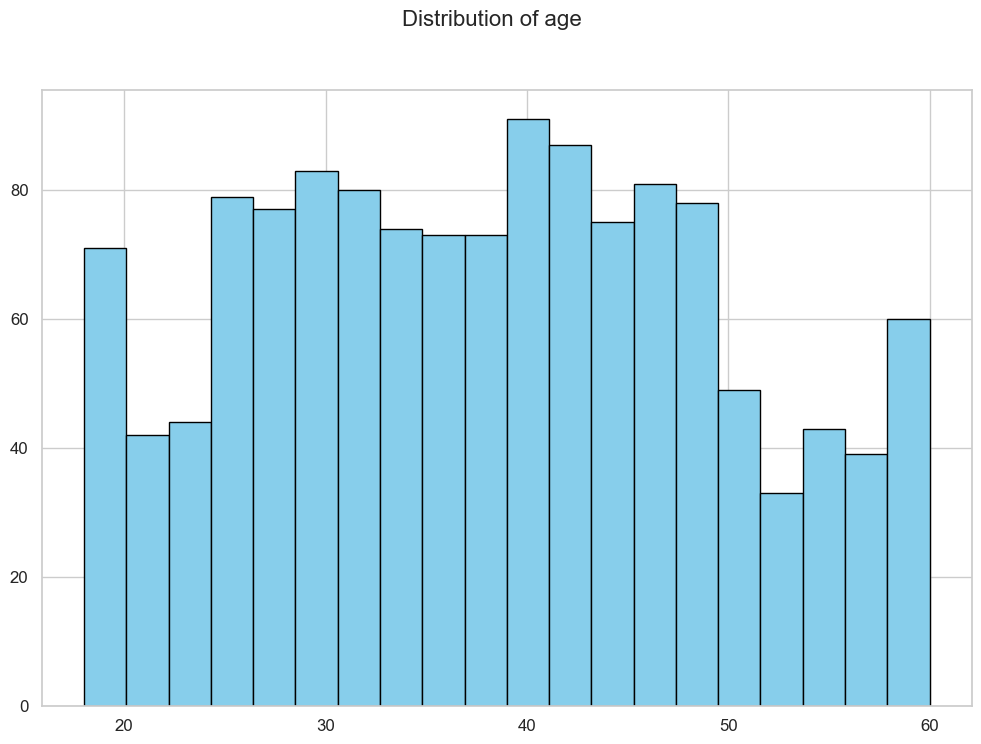

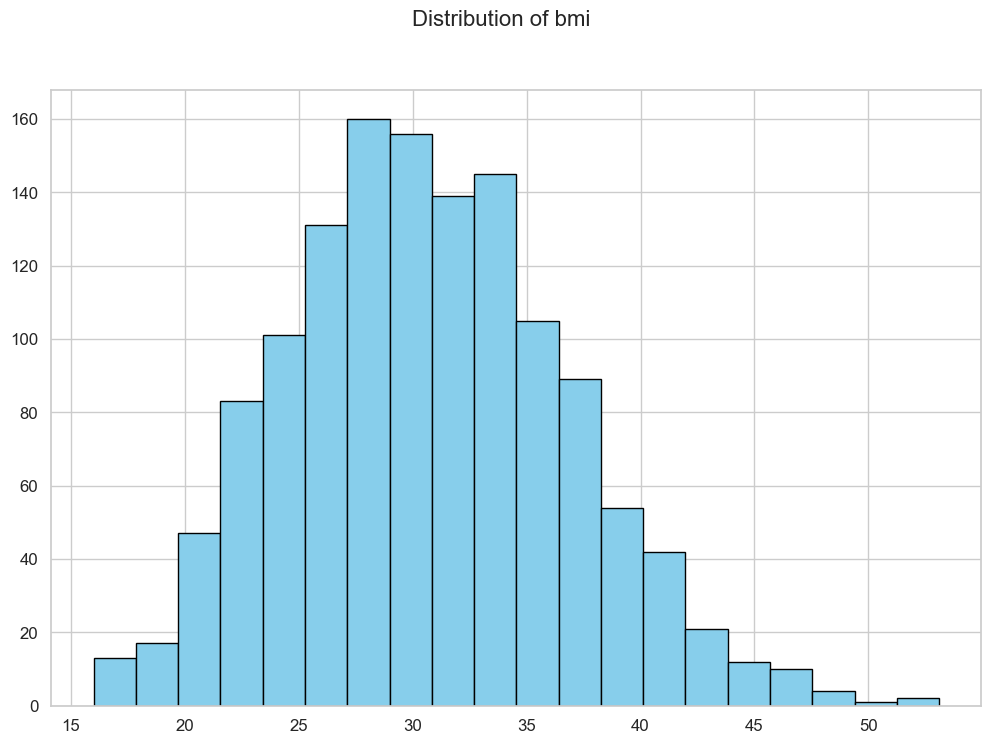

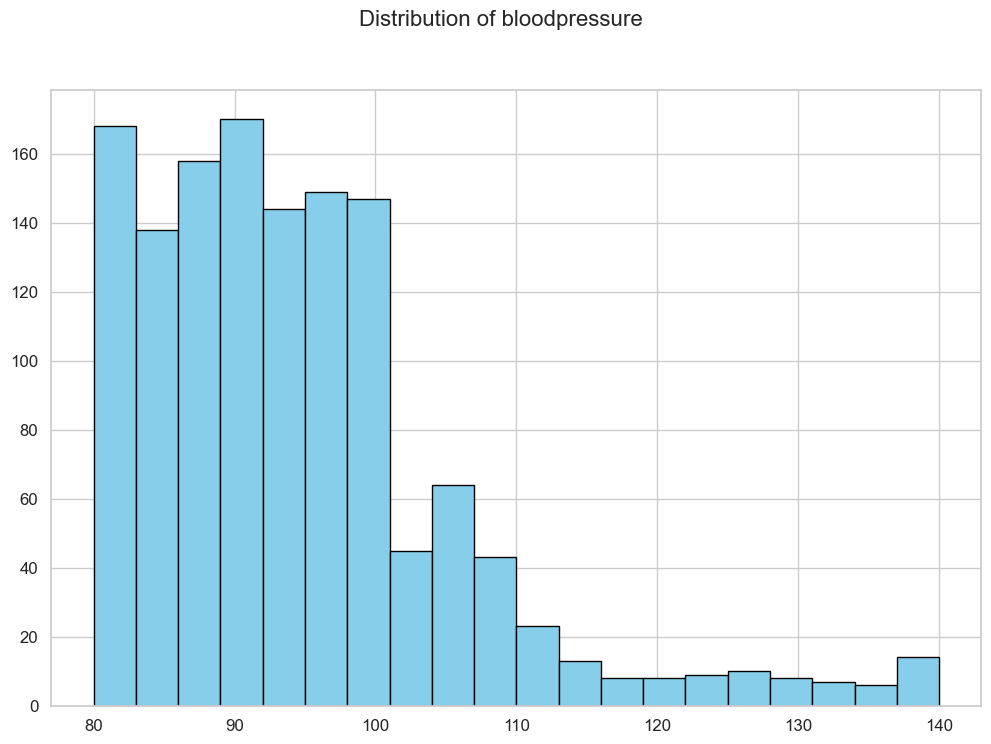

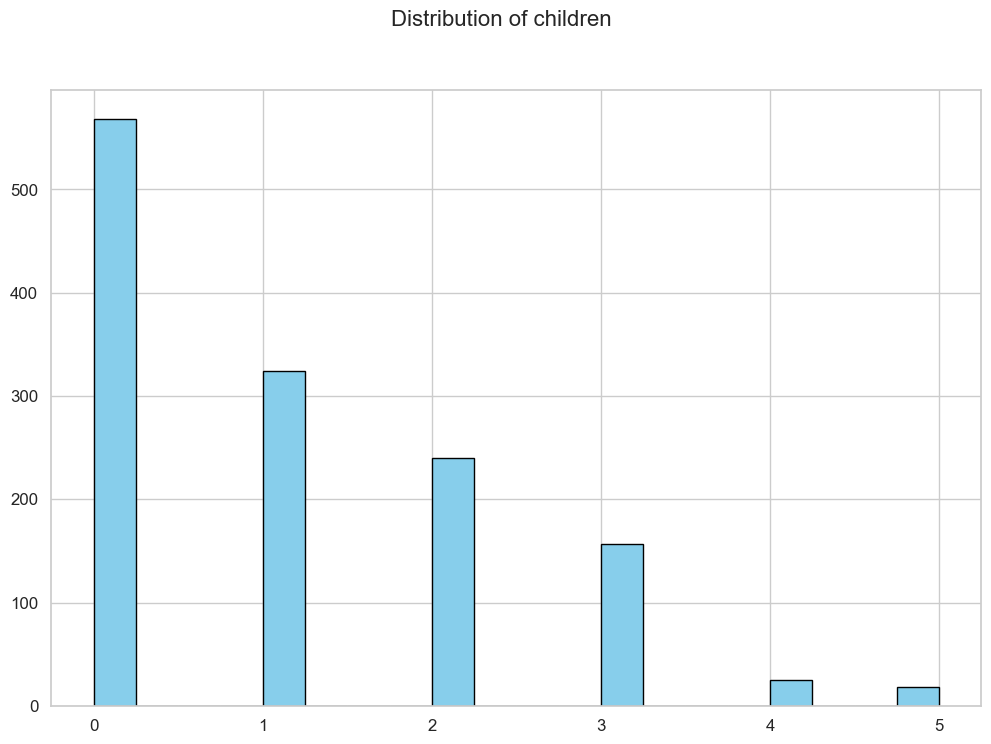

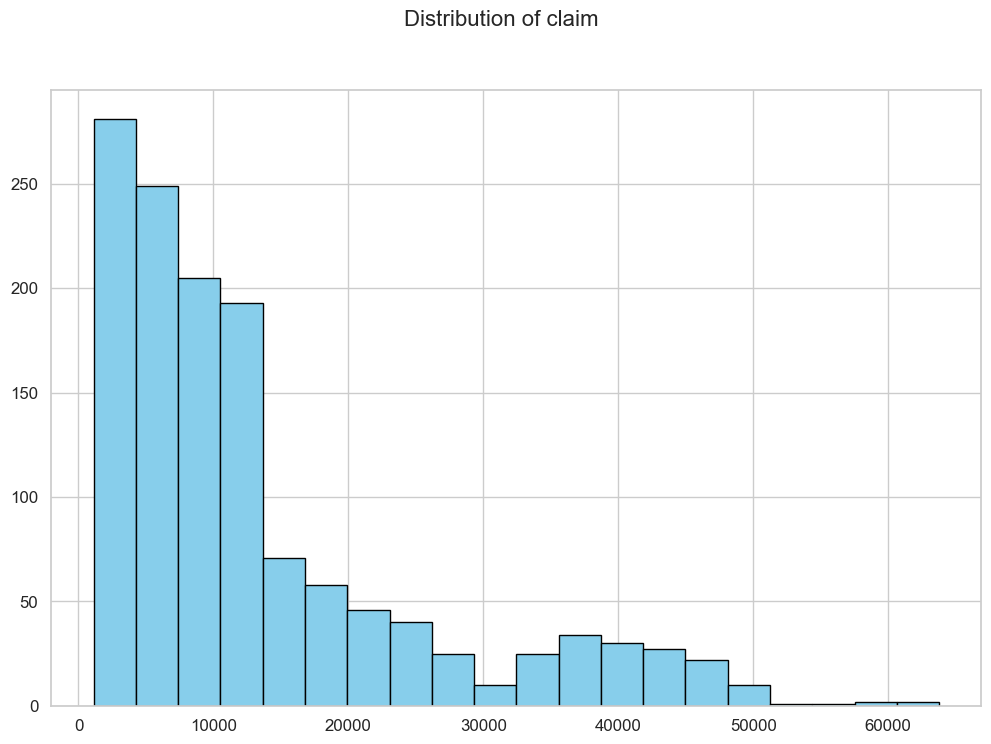

In [155]:
num_cols=['age','bmi','bloodpressure','children','claim']
for col in num_cols:
    df[col].hist(bins=20,figsize=(12,8), color="skyblue",edgecolor="black")
    plt.suptitle(f"Distribution of {col}",fontsize=16)
    plt.show()

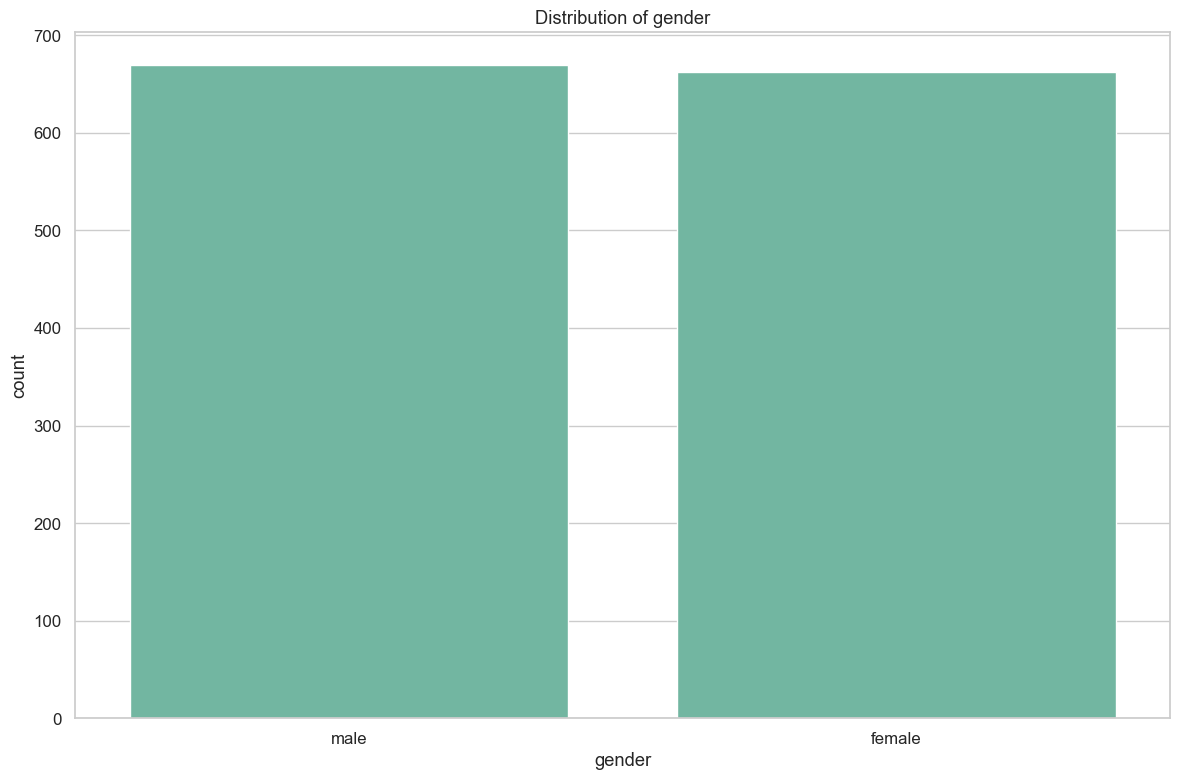

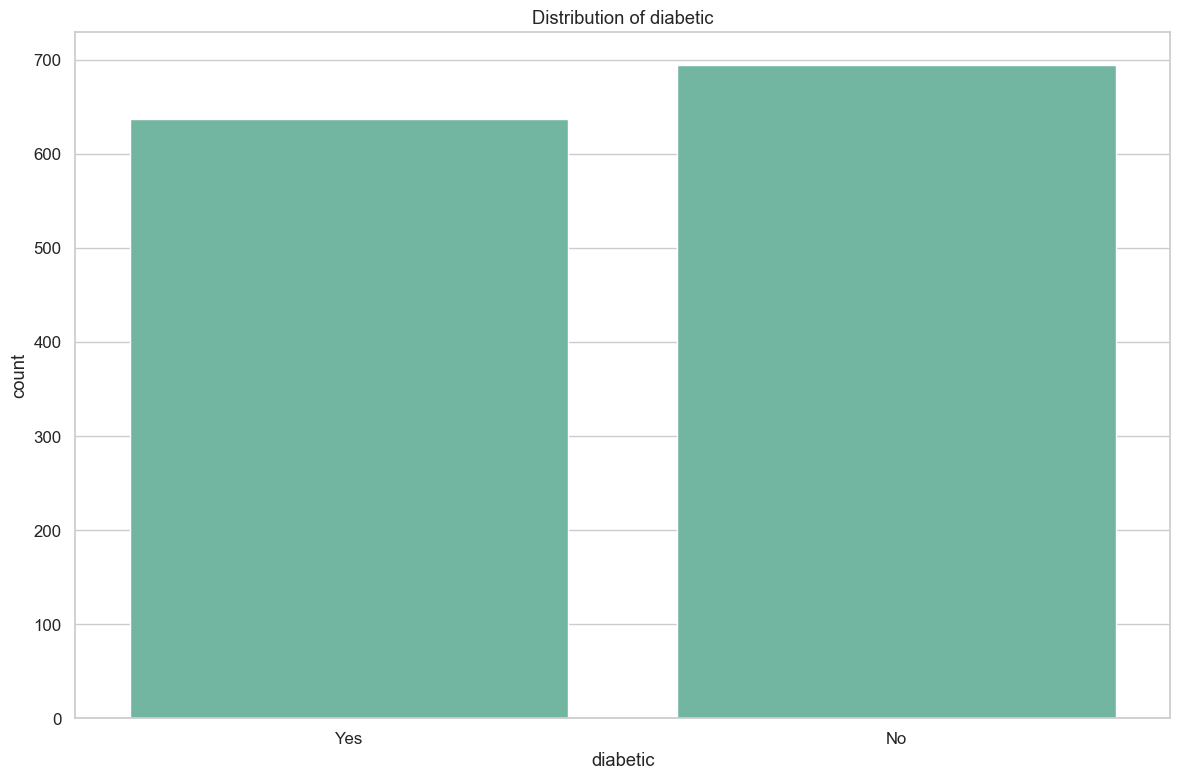

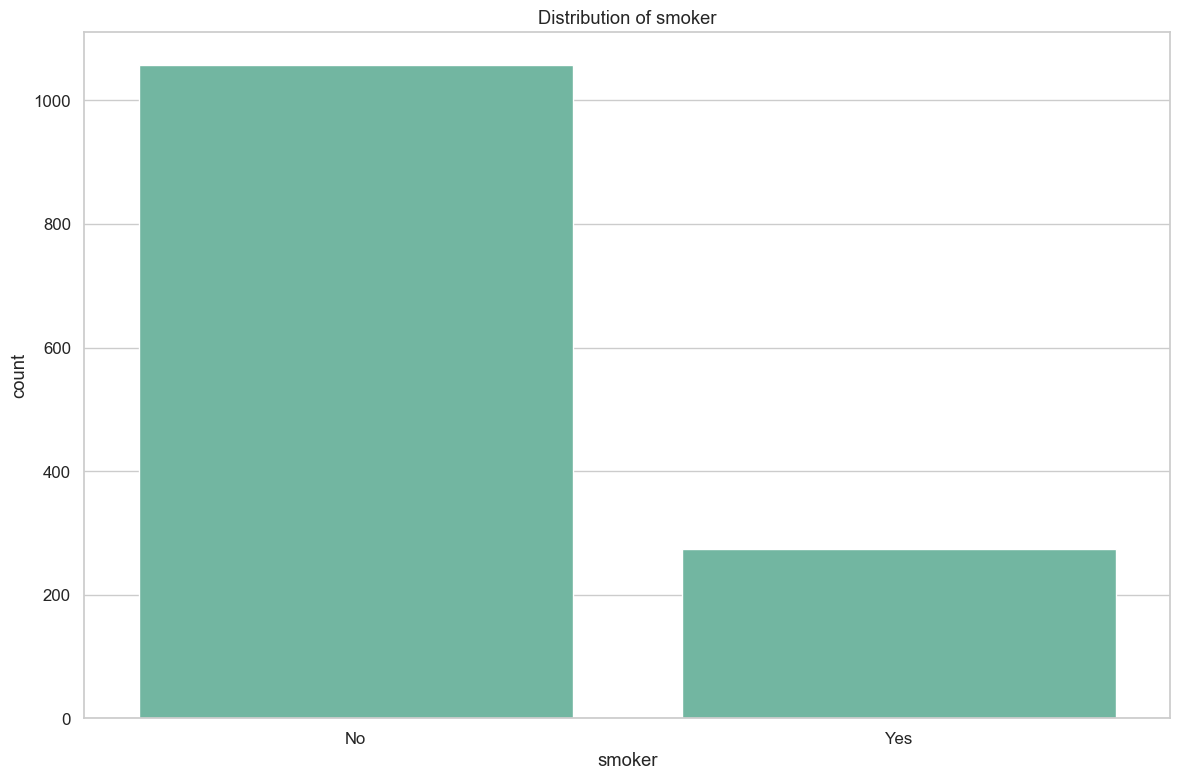

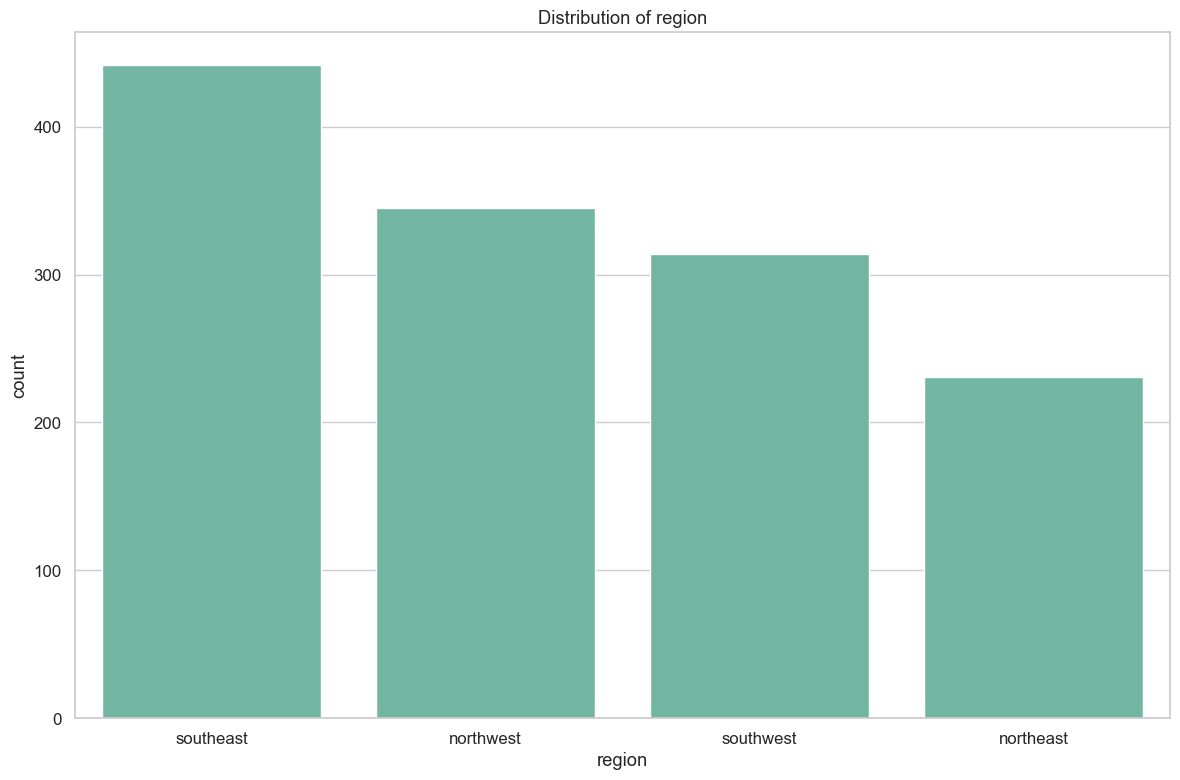

In [156]:
cat_cols=['gender','diabetic','smoker','region']
for cols in cat_cols:
    plt.figure(figsize=(12,8))
    sns.countplot(data=df,x=cols)
    plt.title(f"Distribution of {cols}")
    plt.tight_layout()
    plt.show()
    

In [157]:
df.groupby(['gender','smoker'])['claim'].mean()

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

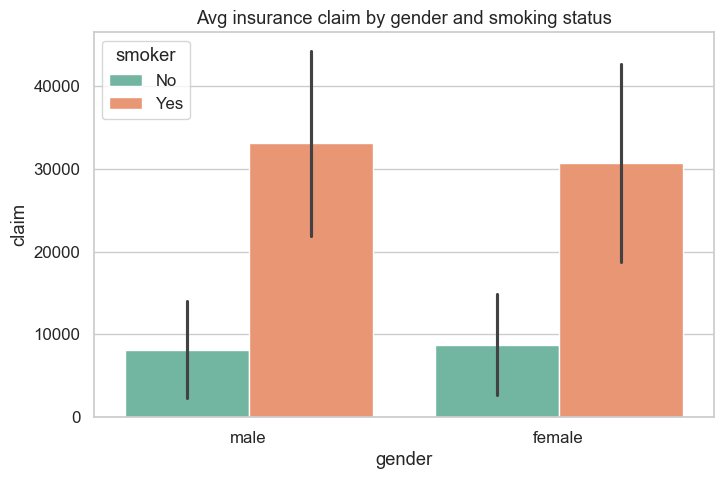

In [158]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="gender",y="claim",hue="smoker",estimator="mean",errorbar="sd")
plt.title("Avg insurance claim by gender and smoking status")
plt.show()

In [159]:
pivot_region_diabetic=df.groupby(['region','diabetic'])['claim'].mean().unstack()

In [160]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


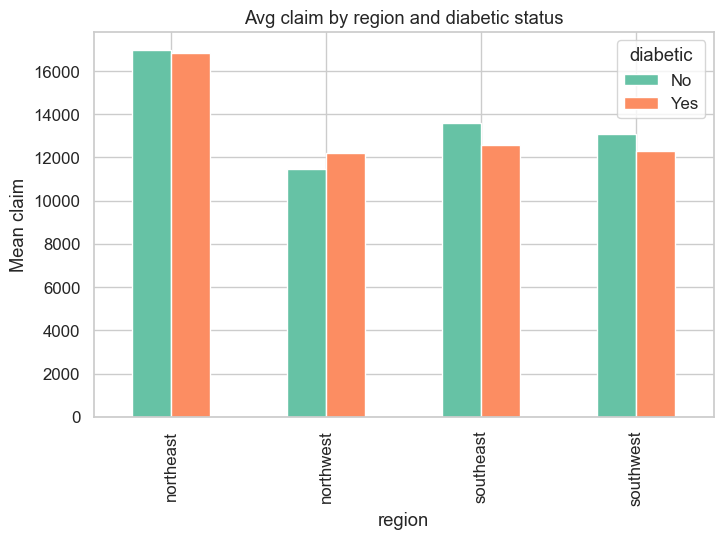

In [161]:
pivot_region_diabetic.plot(kind="bar",figsize=(8,5))
plt.title("Avg claim by region and diabetic status")
plt.xlabel("region")
plt.ylabel("Mean claim")
plt.show()

In [162]:
pivot_table=pd.pivot_table(df,values="claim",index="region",columns="smoker",aggfunc="mean")

pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [163]:
pivot_table=pd.pivot_table(df, values="claim",columns="diabetic",index="children",aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [164]:
df[num_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


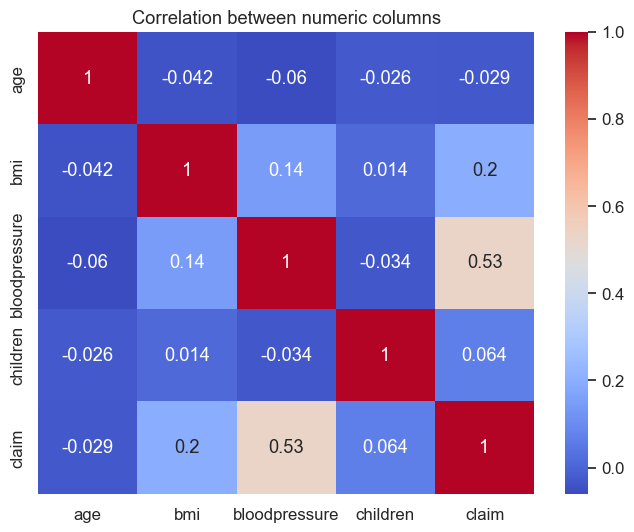

In [165]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation between numeric columns")
plt.show()

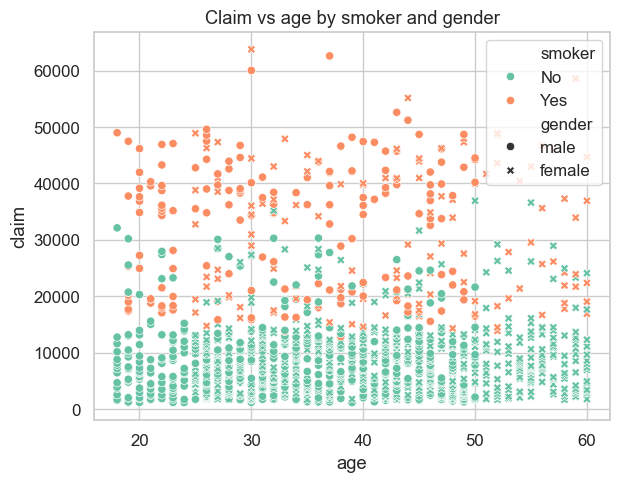

In [166]:
sns.scatterplot(data=df,x="age",y="claim",hue="smoker",style="gender")
plt.tight_layout()
plt.title("Claim vs age by smoker and gender")
plt.show()

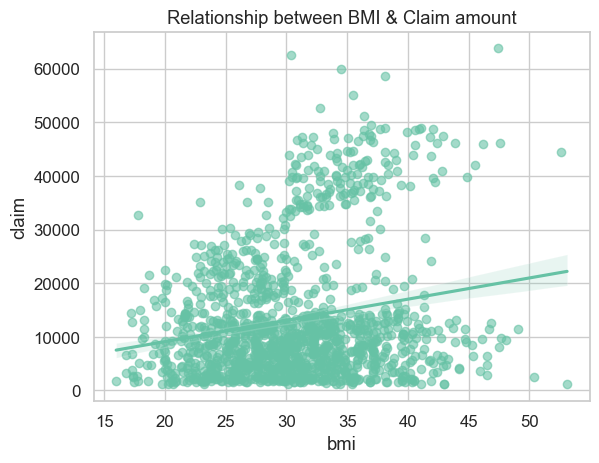

In [167]:
sns.regplot(data=df,x="bmi",y="claim",scatter_kws={"alpha":0.6})
plt.title("Relationship between BMI & Claim amount")
plt.show()


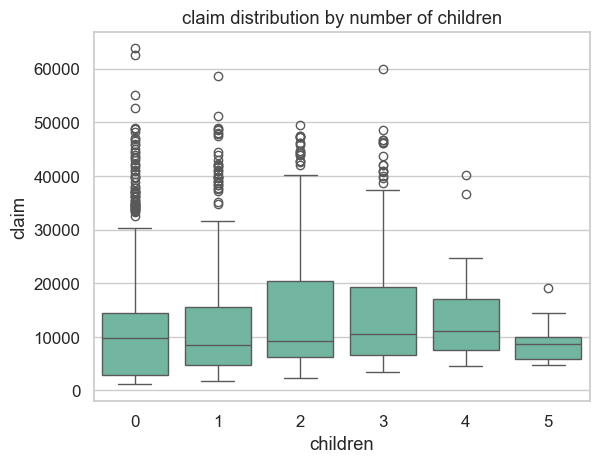

In [168]:
sns.boxplot(data=df,x="children",y="claim")
plt.title("claim distribution by number of children")
plt.show()

In [169]:
df['age_group']=pd.cut(df['age'],bins=[0,18,30,45,60,100],labels={"<18","18-30","31-45","46-60","60+"})
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,60+
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,<18
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,<18
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,<18
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,<18
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,60+
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,<18
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,60+


In [170]:
df["age_group"].value_counts()

age_group
60+      553
46-60    383
<18      380
31-45     16
18-30      0
Name: count, dtype: int64

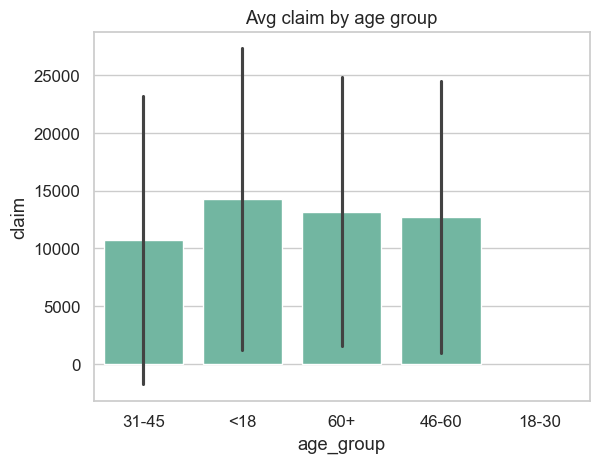

In [171]:
sns.barplot(data=df,x="age_group",y="claim",estimator="mean",errorbar="sd")
plt.title("Avg claim by age group")
plt.show()

In [172]:
df["bmi_category"]=pd.cut(df["bmi"],bins=[0,18.5,24.9,29.9,100],labels=["underweight","normal","overweight","obese"])

In [173]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group,bmi_category
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,60+,normal
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,<18,obese
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,<18,obese
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,<18,obese
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,<18,obese
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,60+,obese
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60,obese
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,<18,obese
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,60+,obese


In [174]:
df["bmi_category"].value_counts()

bmi_category
obese          702
overweight     387
normal         222
underweight     21
Name: count, dtype: int64

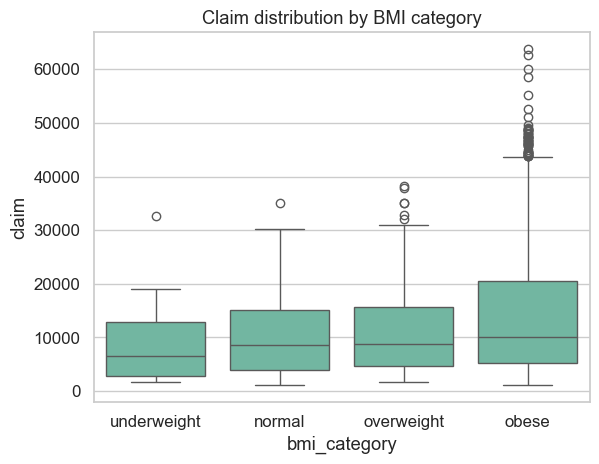

In [175]:
sns.boxplot(data=df,x='bmi_category',y='claim')
plt.title("Claim distribution by BMI category")
plt.show()

In [176]:
region_stats = df.groupby("region").agg(
    smoker_rate=("smoker", lambda x: (x.astype(str).str.strip().str.lower() == "yes").mean() * 100),
    mean_claim=("claim", "mean")
).reset_index()

In [177]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


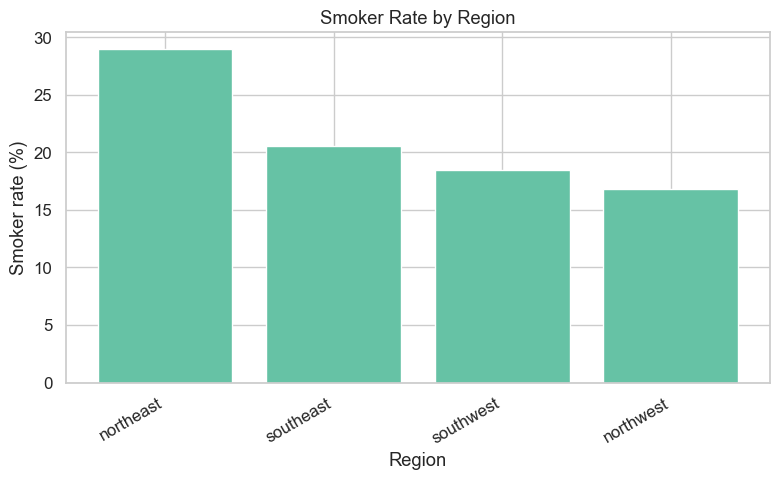

In [178]:
import matplotlib.pyplot as plt

plot_df = region_stats.sort_values("smoker_rate", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(plot_df["region"], plot_df["smoker_rate"])
plt.xlabel("Region")
plt.ylabel("Smoker rate (%)")
plt.title("Smoker Rate by Region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [179]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [180]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group,bmi_category
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,60+,normal
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,<18,obese
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,<18,obese
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,<18,obese
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,<18,obese
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,60+,obese
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60,obese
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,<18,obese
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,60+,obese


In [181]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [182]:
X=df[['age','gender','bmi','bloodpressure','diabetic','children','smoker']]
y=df['claim']

In [183]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [202]:
import joblib
from sklearn.preprocessing import LabelEncoder

cat_cols = ['gender', 'diabetic', 'smoker']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    joblib.dump(le, f"{col}.pkl")

C:\Users\User\AppData\Local\Temp\ipykernel_7964\3547439747.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\User\AppData\Local\Temp\ipykernel_7964\3547439747.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\User\AppData\Local\Temp\ipykernel_7964\3547439747.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [185]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [186]:
num_cols=["age","bmi","bloodpressure","children"]
scaler=StandardScaler()

In [187]:
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [188]:
import joblib
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [189]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [190]:
print(X_test.shape,y_test.shape)

(267, 7) (267,)


In [191]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [192]:
def evaluate_model(model,X_train,X_test,y_train,y_test):
    y_pred=model.predict(X_test)
    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    return {"R2:" :r2,"MAE: ":mae,"RMSE: ":rmse}

In [193]:
result={}

In [194]:
lr=LinearRegression()
lr.fit(X_train,y_train)
result["LinearRegression"]=evaluate_model(lr,X_train,X_test,y_train,y_test)
print("Linear Regression model trained")

best_poly_model=None
best_poly_score=-np.inf

for degree in[2,3]:
    poly=PolynomialFeatures(degree=degree)
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.transform(X_test)
    
    poly_lr=LinearRegression()
    poly_lr.fit(X_train_poly,y_train)
    
    score=poly_lr.score(X_test_poly,y_test)
    
    if score>best_poly_score:
        best_poly_score=score
        best_poly_model=(degree,poly,poly_lr)
        
    degree,poly,poly_lr=best_poly_model
    result[f"Polynomial Regression (deg={degree})"]=evaluate_model(poly_lr,poly.fit_transform(X_train),poly.transform(X_test),y_train,y_test)
    print("polynomial regression model trained")
    
    rf=RandomForestRegressor()
    rf_params={
        "n_estimators": [100,200],
        "max_depth":[None,10,20],
        "min_samples_split":[2,5],
        "min_samples_leaf":[1,2]
    }
    rf_grid=GridSearchCV(rf,rf_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
    rf_grid.fit(X_train,y_train)
    best_rf=rf_grid.best_estimator_
    
    result["Random Forest"]=evaluate_model(best_rf,X_train,X_test,y_train,y_test)
    print("Random forest training is completed,best_parameters: ",best_rf)
    
    svr=SVR()
    svr_params={
        "kernel":["rbf","poly","linear"],
        "C":[1,10,50],
        "epsilon":[0.1,0.2,0.5],
        "degree":[2,3]
    }
    
    svr_grid=GridSearchCV(svr,svr_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
    
    svr_grid.fit(X_train,y_train)
    best_svr=svr_grid.best_estimator_
    
    result["SVR"]=evaluate_model(best_svr,X_train,X_test,y_train,y_test)
    
    print("SVR training is completed, best parameters: ",best_svr)

Linear Regression model trained
polynomial regression model trained
Random forest training is completed,best_parameters:  RandomForestRegressor(max_depth=10, min_samples_leaf=2)
SVR training is completed, best parameters:  SVR(C=50, degree=2, epsilon=0.5, kernel='linear')
polynomial regression model trained
Random forest training is completed,best_parameters:  RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200)
SVR training is completed, best parameters:  SVR(C=50, degree=2, epsilon=0.5, kernel='linear')


In [195]:
result

{'LinearRegression': {'R2:': 0.7186402865210724,
  'MAE: ': 5034.263198897407,
  'RMSE: ': np.float64(6368.137982018984)},
 'Polynomial Regression (deg=2)': {'R2:': 0.7757814325424963,
  'MAE: ': 4426.321815178741,
  'RMSE: ': np.float64(5684.827554251739)},
 'Random Forest': {'R2:': 0.8257341709275937,
  'MAE: ': 3856.0424294338104,
  'RMSE: ': np.float64(5011.729548406855)},
 'SVR': {'R2:': 0.4979929465562679,
  'MAE: ': 5916.9074098768515,
  'RMSE: ': np.float64(8506.21622300923)}}

In [196]:
result_df=pd.DataFrame(result).T.sort_values(by="R2:",ascending=False)

result_df

,R2:,MAE:,RMSE:
Random Forest,0.83,3856.04,5011.73
Polynomial Regression (deg=2),0.78,4426.32,5684.83
LinearRegression,0.72,5034.26,6368.14
SVR,0.50,5916.91,8506.22


In [197]:
best_r2=result_df["R2:"].max()
best_r2

np.float64(0.8257341709275937)

In [198]:
top_model=result_df[result_df["R2:"]==best_r2]

In [199]:
top_model

,R2:,MAE:,RMSE:
Random Forest,0.83,3856.04,5011.73


In [204]:
joblib.dump(best_rf, "best_model.pkl")

['best_model.pkl']